<a href="https://colab.research.google.com/github/ixchelmaertens/connectatel-analisis-comportamiento-usuarios/blob/main/connectatel_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Análisis de Comportamiento de Usuarios — ConnectaTel 2024

**Autora:** Alison Ixchel Maertens Gaona  
**Herramientas:** Python · pandas · numpy · seaborn · matplotlib  
**Fuentes:** plans.csv · users_latam.csv · usage.csv  

# Contexto
Como analista de datos en ConnectaTel, empresa de telecomunicaciones
con operaciones en México y Colombia, el objetivo es construir un
perfil estadístico de los clientes, detectar comportamientos atípicos
y crear segmentos de usuarios para optimizar la oferta comercial
y mejorar la experiencia del usuario.

# Preguntas de negocio
1. ¿Qué segmentos muestran mayor o menor uso de llamadas y mensajes?
2. ¿Qué usuarios presentan valores atípicos que indiquen comportamientos
   inusuales, fraude o errores de registro?
3. ¿Cómo varía el uso según edad y tipo de plan contratado?
4. ¿Qué patrones ayudan a diseñar mejores planes y mejorar la
   satisfacción del cliente?

## Ingesta de Datos y Análisis Exploratorio Inicial (EDA)

Esta fase cubre la carga de las tres fuentes de datos, la validación
de su integridad estructural y la detección preliminar de anomalías
antes de iniciar el proceso de limpieza.

### Carga de Fuentes y Visualización Preliminar

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carga de fuentes de datos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# Inspección preliminar — Catálogo de planes
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# Inspección preliminar — Maestro de usuarios
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# Inspección preliminar — Registro de uso
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### Auditoría Estructural de los Datasets

In [ ]:
# Volumetría de cada fuente (filas × columnas)
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [ ]:
# Diagnóstico estructural — plans
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Diagnóstico estructural — users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# Diagnóstico estructural — usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## Identificación de Problemas de Calidad de Datos

### Diagnóstico de Valores Nulos

In [ ]:
# Magnitud y proporción de nulos — users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# Magnitud y proporción de nulos — usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


#### Reporte de Valores Nulos
**Dataset `plans`:**
- Solo cuenta con 2 renglones y se puede observar no tiene ausentes, por ello no necesita exploración adicional.

**Dataset `users`:**
- `city`: 11.73% de nulos → Se imputará con `"unknown"` para
  preservar la integridad geográfica sin sesgar hacia la moda
- `churn_date`: 88.35% de nulos → Se ignorará; no forma parte
  del alcance analítico de este estudio

**Dataset `usage`:**
- `date`: 0.13% de nulos → Se dejan como nulos; volumen
  insignificante que no afecta el análisis
- `duration`: 55.19% de nulos → Se imputará con `0` únicamente
  en filas que tengan valor en `length` (registros de tipo texto)
- `length`: 44.74% de nulos → Se imputará con `0` únicamente
  en filas que tengan valor en `duration` (registros de tipo llamada)

### 2.2 Detección de Valores Inválidos y Sentinels

In [ ]:
# Perfil estadístico de columnas numéricas — users
users_numericas = ['age']
users[users_numericas].describe()

,age
count,4000.000000
mean,33.739750
std,123.232257
min,-999.000000
25%,32.000000
50%,47.000000
75%,63.000000
max,79.000000


- `user_id`: Identificador categórico único por usuario,
  no opera como variable numérica
- `age`: Contiene sentinel `-999` que distorsiona media y
  desviación estándar → Se imputará por la mediana

In [ ]:
# Perfil estadístico de columnas numéricas — usage
usage_numericas = ['duration', 'length']
usage[usage_numericas].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- `id` y `user_id`: Identificadores categóricos, no variables numéricas
- `duration`: Media y mediana significativamente diferentes,
  indicando presencia de outliers superiores (máx: 120); desviación estándar elevada
- `length`: Media y mediana cercanas a pesar de outlier superior
  (máx: 1,490); desviación estándar elevada

In [ ]:
# Exploración de columnas categóricas — users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].unique())
users[columnas_user].describe()

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- `city`: 7 valores únicos; Bogotá es la ciudad más frecuente (808 registros)
- `plan`: 2 valores únicos; Básico es el plan predominante (2,595 registros)

In [ ]:
# Exploración de columnas categóricas — usage
columnas_usage = ['type']
print(usage['type'].unique())
usage[columnas_usage].describe()

['call' 'text']


,type
count,40000
unique,2
top,text
freq,22092


- `type`: 2 valores únicos; `text` es el tipo más frecuente (22,092 registros)

#### Reporte de Sentinels y Valores Inválidos

- `age` (users): Sentinel `-999` → Imputar por mediana de la columna
- `city` (users): Sentinel `"?"` → Reemplazar por `"unknown"`

###  Revisión y Estandarización de Fechas

In [ ]:
# Conversión a datetime — reg_date en users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Conversión a datetime — date en usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Distribución de años — reg_date
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

In [ ]:
# Distribución de años — date en usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

#### Reporte de Fechas Fuera de Rango

**`reg_date` (users):**
- Años presentes: 2022, 2023, 2024 y 2026
- El año 2025 está ausente, interrumpiendo la continuidad cronológica
- El año 2026 se clasifica como inconsistente: dado que el dataset
  `usage` está basado en 2024, este año no había transcurrido al
  momento del registro
- Acción: Por su baja proporción (~1%) y tratarse de un error
  de captura probable, se imputará por 2024 y se documentará
  en el README del repositorio

**`date` (usage):**
- Año único: 2024 con 50 nulos (ya identificados en sección 2.1)
- Se usará 2024 como ventana temporal del análisis

## Limpieza y Normalización de Datos

### Corrección de Sentinels y Fechas Fuera de Rango

In [ ]:
# Imputación del sentinel -999 en age por mediana
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Validación
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazo del sentinel "?" en city por "unknown"
users['city'] = users['city'].replace('?', 'unknown')

# Validación
users['city'].unique()

array(['Medellín', 'unknown', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
# Corrección de fechas fuera de rango en reg_date (año 2026 → 2024)
users['reg_date'] = users['reg_date'].apply(
    lambda x: x.replace(year=2024) if pd.notna(x) and x.year == 2026 else x
)

# Validación
users['reg_date'].dt.year.unique()

array([2022, 2024, 2023])

### Tratamiento de Valores Nulos por Mecanismo MAR

In [ ]:
# Verificación MAR — proporción de nulos en duration por tipo de uso
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR — proporción de nulos en length por tipo de uso
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

#### Diagnóstico de Mecanismo de Nulos (MAR)

El análisis confirma que los valores faltantes son **MAR
(Missing At Random)**, condicionados por la variable `type`:

- Cuando `type = text` → `duration` es nula en **99.92%** de los casos
- Cuando `type = call` → `length` es nula en **99.93%** de los casos

La ausencia del dato está estructuralmente explicada por la naturaleza
del servicio: los mensajes no tienen duración y las llamadas no tienen
longitud de texto. Imputar estos valores distorsionaría las
distribuciones reales de cada servicio.

**Decisión:** Conservar como nulos. El remanente (~0.08%)
se aísla y documenta como caso de investigación adicional.

## Construcción del Perfil Estadístico de Usuarios

### Agregación de Métricas de Comportamiento por Usuario

In [ ]:
# Columnas auxiliares para conteo por tipo de evento
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

# Agregación de métricas de uso por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']]\
    .agg('sum').reset_index()

# Validación
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Estandarización de nomenclatura de columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# Validación
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Fusión del perfil de uso con el maestro de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Imputación de usuarios sin registros de uso (Left Join → posibles nulos)
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Validación
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### Resumen Estadístico del Perfil de Usuarios (2024)

In [ ]:
# Perfil estadístico de variables numéricas clave
col_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[col_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.122250,5.523000,4.477000,23.311225
std,17.690408,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual por tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

## Análisis Visual de Distribuciones y Detección de Outliers

### Distribución de Variables Clave por Tipo de Plan

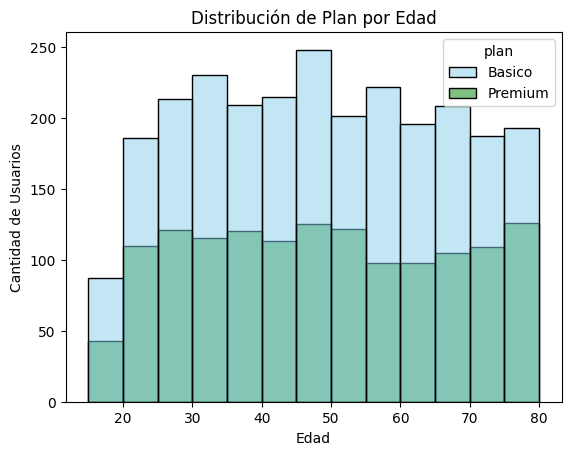

In [ ]:
# Distribución de edad por plan
sns.histplot(user_profile, x='age', bins=13, binrange=(15, 80),
             hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Plan por Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Insights — Edad:
- **Distribución:** Uniforme entre 20 y 80 años con ligera
  concentración entre 45 y 50 años
- **Proporción:** Base de clientes equilibrada entre ambos planes
  en todos los rangos de edad, sin segmentación etaria marcada

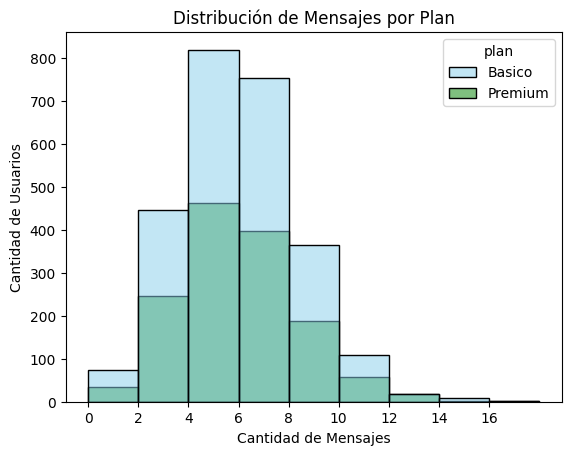

In [ ]:
# Distribución de mensajes por plan
bin_edges = np.arange(0, 18, 2)
sns.histplot(user_profile, x='cant_mensajes', bins=9, binrange=(0, 18),
             hue='plan', palette=['skyblue', 'green'])
plt.xticks(bin_edges)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Insights — Mensajes:
- **Distribución:** Sesgada a la derecha; mayoría de usuarios envía
  entre 4 y 8 mensajes. Usuarios con más de 12 mensajes son minoría
- **Proporción:** Distribución similar entre planes para 0-12 mensajes;
  usuarios con más de 12 mensajes se concentran exclusivamente en
  el segmento Premium

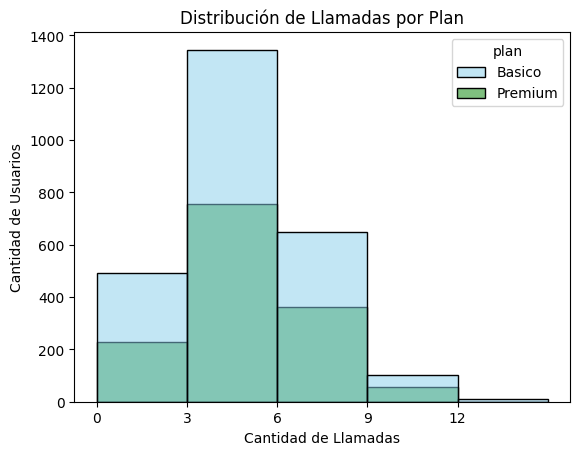

In [ ]:
# Distribución de llamadas por plan
bin_edges = np.arange(0, 15, 3)
sns.histplot(user_profile, x='cant_llamadas', bins=5, binrange=(0, 15),
             hue='plan', palette=['skyblue', 'green'])
plt.xticks(bin_edges)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Insights — Llamadas:
- **Distribución:** Sesgada a la derecha; concentración principal
  entre 3 y 6 llamadas. Usuarios con más de 12 llamadas son muy escasos
- **Proporción:** Usuarios Premium predominan en casi todos los
  rangos de llamadas

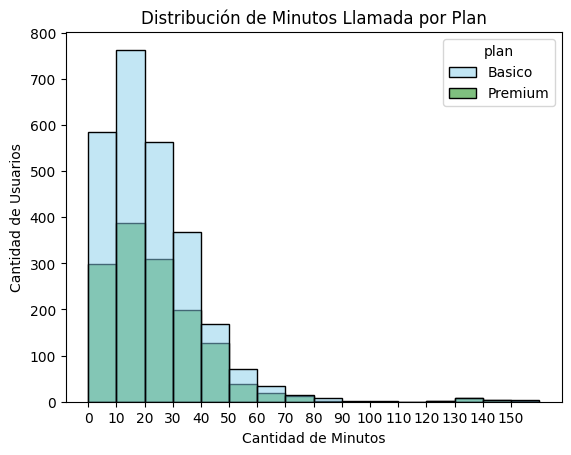

In [ ]:
# Distribución de minutos de llamada por plan
bin_edges = np.arange(0, 156, 10)
sns.histplot(user_profile, x='cant_minutos_llamada', bins=16, binrange=(0, 160),
             hue='plan', palette=['skyblue', 'green'])
plt.xticks(bin_edges)
plt.title('Distribución de Minutos Llamada por Plan')
plt.xlabel('Cantidad de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Insights — Minutos de Llamada:
- **Distribución:** Fuertemente sesgada a la derecha; concentración
  en 0-30 minutos con valle marcado entre 90-130 minutos
- **Proporción:** Usuarios Premium predominan en todos los rangos
  de minutos sin excepción

### Detección y Tratamiento de Outliers

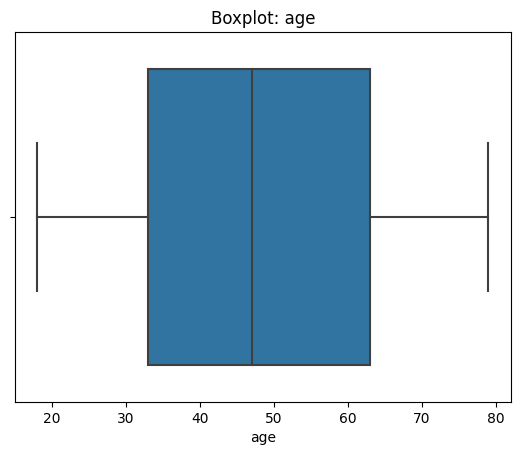

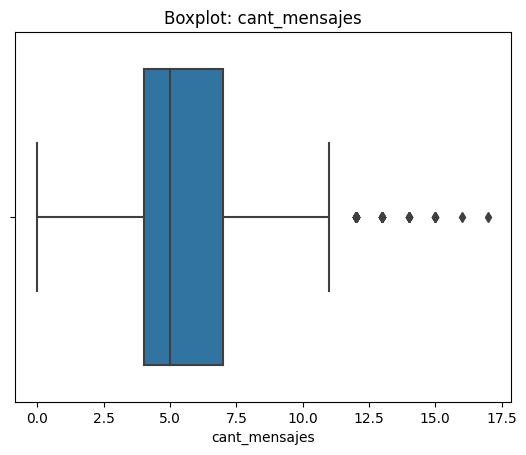

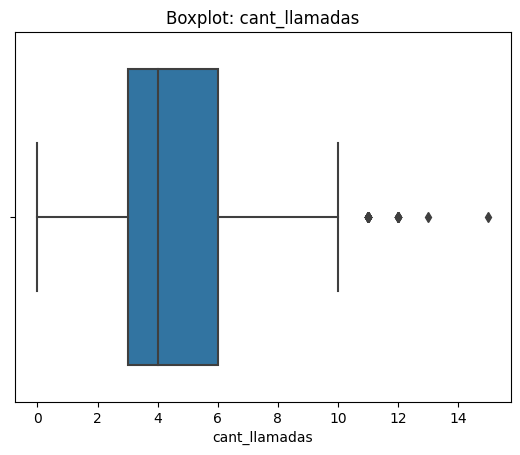

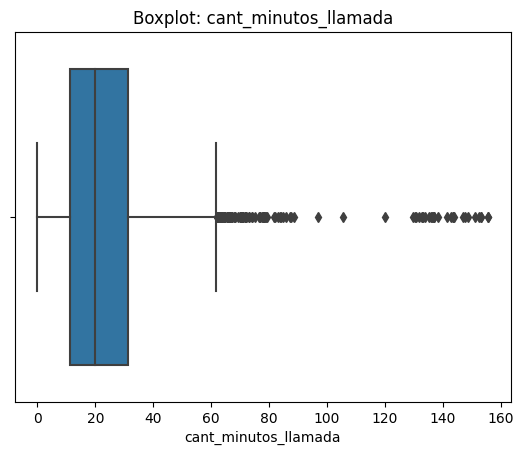

In [ ]:
# Visualización de outliers mediante boxplots
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.xlabel(col)
    plt.title(f'Boxplot: {col}')
    plt.show()

#### Diagnóstico de Outliers:
- `age`: Sin outliers — rango válido de 18 a 79 años,
  IQR concentrado entre 35 y 65 años
- `cant_mensajes`: Outliers superiores entre 12 y 17 mensajes;
  IQR en 4-7 mensajes
- `cant_llamadas`: Outliers superiores entre 11 y 15 llamadas;
  IQR en 3-6 llamadas
- `cant_minutos_llamada`: Outliers superiores desde 60 hasta
  160 minutos; IQR en 10-30 minutos

In [ ]:
# Cálculo de límites superiores mediante método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
limites_superiores = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    limites_superiores[col] = upper_limit
    print(f"Límite superior IQR para {col}: {upper_limit}")

Límite superior IQR para cant_mensajes: 11.5
Límite superior IQR para cant_llamadas: 10.5
Límite superior IQR para cant_minutos_llamada: 61.870000000000005


In [ ]:
# Referencia estadística para decisión de cappeo
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


#### Decisión de Tratamiento — Cappeo por Límites de Negocio:

Se aplica cappeo con límites personalizados en lugar de los
límites IQR estrictos, priorizando la retención del registro
del cliente sin distorsionar la media ni los modelos predictivos:

| Variable | Límite IQR | Límite Aplicado | Justificación |
|---|---|---|---|
| `cant_mensajes` | ~11.5 | 12 | Conserva usuarios de alto uso real |
| `cant_llamadas` | ~10.5 | 11 | Margen para usuarios muy activos |
| `cant_minutos_llamada` | ~61.87 | 65 | Cubre casos legítimos de uso intenso |

In [ ]:
# Cappeo con límites personalizados de negocio
limites_personalizados = {
    'cant_mensajes': 12,
    'cant_llamadas': 11,
    'cant_minutos_llamada': 65
}

for col in limites_superiores:
    user_profile[col] = user_profile[col].clip(None,limites_personalizados[col])

# Validación de nuevos máximos
print(user_profile[list(limites_personalizados.keys())].max())

cant_mensajes           12.0
cant_llamadas           11.0
cant_minutos_llamada    65.0
dtype: float64


## Segmentación de Clientes

### Segmentación por Nivel de Uso

In [ ]:
# Clasificación de clientes por nivel de uso (llamadas y mensajes)
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    if pd.isna(llamadas) or pd.isna(mensajes):
        return 'Error en Datos'
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile[['cant_mensajes', 'cant_llamadas']].apply(clasificar_uso, axis=1)

# Validación
print(user_profile['grupo_uso'].value_counts())
user_profile.head()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### Segmentación por Grupo Etario

In [ ]:
# Clasificación de clientes por grupo etario
def clasificar_edad(row):
    edad = row['age']
    if pd.isna(edad):
        return 'Error en Datos'
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile[['age']]\
    .apply(clasificar_edad, axis=1)

# Validación
print(user_profile['grupo_edad'].value_counts())
user_profile.head()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### Visualización de Segmentos

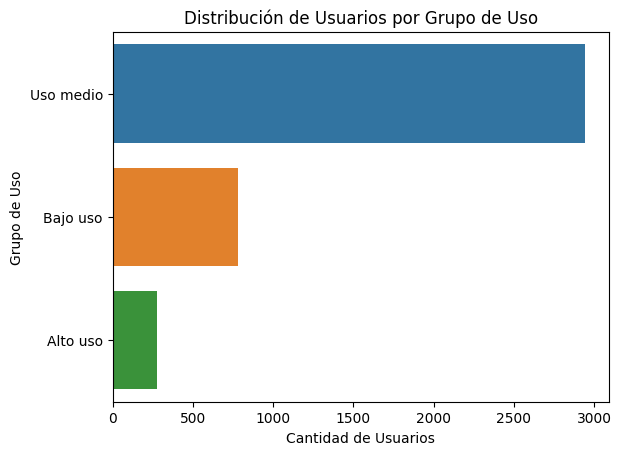

In [ ]:
# Distribución de usuarios por nivel de uso
sns.countplot(data=user_profile, y='grupo_uso',
              order=user_profile['grupo_uso'].value_counts().index)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Grupo de Uso')
plt.show()

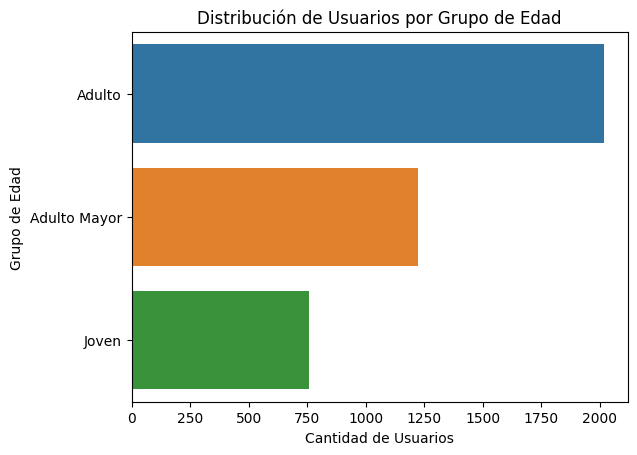

In [ ]:
# Distribución de usuarios por grupo etario
sns.countplot(data=user_profile, y='grupo_edad',
              order=user_profile['grupo_edad'].value_counts().index)
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Grupo de Edad')
plt.show()

#### Insights — Segmentación:

**Por nivel de uso:**
- El segmento **Uso medio** domina ampliamente (~3,000 usuarios), lo que indica que la mayoría de clientes tiene un comportamiento de consumo moderado y consistente
- El segmento **Bajo uso** (~750 usuarios) representa una oportunidad comercial para campañas de activación
- El segmento **Alto uso** (~250 usuarios) es minoritario pero estratégico — son candidatos naturales para migración al plan Premium

**Por grupo etario:**
- Los **Adultos** (30-59 años) constituyen el segmento más grande (~2,000 usuarios), representando el núcleo de la base de clientes
- Los **Adultos Mayores** (~1,250 usuarios) son el segundo grupo más relevante y pueden requerir planes simplificados
- Los **Jóvenes** (~750 usuarios) son el segmento más pequeño pero con mayor potencial de crecimiento a largo plazo

## Insight Ejecutivo para Stakeholders

### Resumen Ejecutivo

El presente análisis construyó un perfil estadístico completo de los clientes de ConnectaTel a partir de tres fuentes de datos integradas, permitiendo identificar segmentos accionables, comportamientos atípicos y oportunidades comerciales concretas.

---

### ⚠️ Diagnóstico de Calidad de Datos

**Dataset `users`:**

| Columna | Problema | Volumen | Acción |
|---|---|---|---|
| `city` | 469 nulos + sentinel `"?"` | 11.73% | Imputado por `"unknown"` |
| `churn_date` | 3,534 nulos | 88.35% | Columna ignorada fuera de alcance |
| `age` | Sentinel `-999` | Puntual | Imputado por mediana |
| `reg_date` | Fechas en año 2026 | ~1% | Año corregido a 2024 |

**Dataset `usage`:**

| Columna | Problema | Volumen | Acción |
|---|---|---|---|
| `date` | 50 nulos | 0.13% | Conservados — volumen insignificante |
| `duration` | 22,076 nulos | 55.19% | Conservados — MAR condicionado por `type` |
| `length` | 17,896 nulos | 44.74% | Conservados — MAR condicionado por `type` |

---

### 🔍 Segmentación de Clientes

**Por Grupo Etario:**
- **Joven** — menores de 30 años (~750 usuarios)
- **Adulto** — entre 30 y 59 años (~2,000 usuarios)
- **Adulto Mayor** — 60 años o más (~1,250 usuarios)

**Por Nivel de Uso:**
- **Bajo uso** — menos de 5 llamadas y menos de 5 mensajes
- **Uso medio** — no cumple condición de bajo uso pero con menos de 10 llamadas y menos de 10 mensajes (~3,000 usuarios)
- **Alto uso** — 10 o más llamadas o 10 o más mensajes (~250 usuarios)

El perfil predominante es el **Adulto con Uso Medio**, consolidándose como el núcleo comercial más estable de ConnectaTel. Los errores de captura detectados (ciudades inválidas, edades centinela y fechas futuras) sugieren la necesidad de validaciones en el sistema de registro de clientes.

---

### 📊 Patrones de Uso Extremo (Outliers)

Las tres variables de consumo presentaron outliers superiores significativos que fueron tratados mediante cappeo con límites de negocio:

| Variable | Límite Aplicado | Implicación |
|---|---|---|
| `cant_mensajes` | 12 mensajes | Usuarios de alta actividad en texto |
| `cant_llamadas` | 11 llamadas | Usuarios de alta frecuencia de llamadas |
| `cant_minutos_llamada` | 65 minutos | Usuarios con consumo intenso de voz |

Estos patrones extremos representan un segmento minoritario pero de alto valor económico potencial.

---

### 💡 Recomendaciones Estratégicas

**1. Up-selling dirigido (Alto y Medio Uso → Premium):**
Diseñar campañas de migración al plan Premium para clientes del segmento Alto Uso u Uso Medio actualmente en plan Básico, demostrando el ahorro potencial frente al costo por excedente.

**2. Monetización de consumo extremo:**
Crear módulos o add-ons de minutos adicionales micro-tarificados para usuarios con outliers de llamadas (60-160 minutos), convirtiendo el comportamiento extremo en ingreso incremental.

**3. Fidelización del segmento núcleo (Adulto / Uso Medio):**
Implementar programas de renovación de contratos y beneficios de lealtad enfocados en Adultos con Uso Medio — segmento que valora estabilidad y consistencia del servicio sobre funcionalidades premium.

In [ ]:
user_profile.to_csv("user_profile_completo.csv", index=False)

## Análisis Extendido — Iniciativa Propia

Adicional a los entregables del proyecto, se plantearon 3 preguntas de negocio propias para profundizar en la comprensión del
comportamiento de los clientes de ConnectaTel.

---

### ¿Los usuarios con churn_date se concentran en algún plan?

      plan  usuarios_con_churn  porcentaje
0   Basico                 298       63.95
1  Premium                 168       36.05


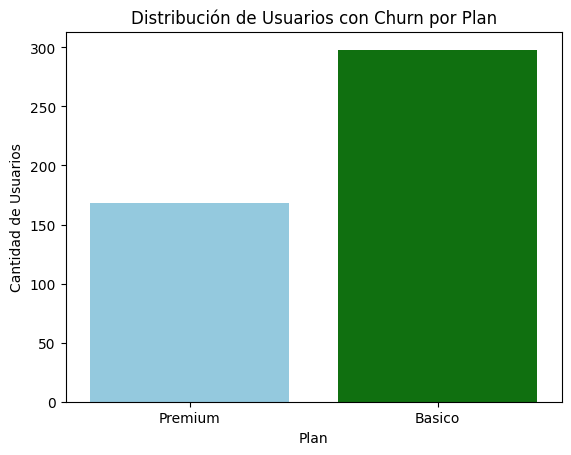

In [ ]:
# Recargar users original para acceder a churn_date
users_raw = pd.read_csv('/datasets/users_latam.csv')

# Identificar usuarios con churn_date registrado
churned = users_raw[users_raw['churn_date'].notna()][['user_id', 'plan']]

# Distribución por plan
churn_por_plan = churned['plan'].value_counts().reset_index()
churn_por_plan.columns = ['plan', 'usuarios_con_churn']
churn_por_plan['porcentaje'] = (
    churn_por_plan['usuarios_con_churn'] / len(churned) * 100
).round(2)

print(churn_por_plan)

# Visualización
sns.countplot(data=churned, x='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Usuarios con Churn por Plan')
plt.xlabel('Plan')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Insights — Churn por Plan:
- El plan **Básico concentra el 63.95%** de las cancelaciones frente al 36.05% del plan Premium
- Sin embargo, esta proporción es consistente con la distribución general de usuarios por plan, por lo que no representa una
  anomalía estadística significativa
- **Recomendación:** Diseñar una campaña de retención dirigida específicamente al segmento Básico para reducir la tasa de
  cancelación, dado que representa el mayor volumen absoluto de bajas (298 usuarios)

### ¿Cómo se conforman los planes Básico y Premium por nivel de uso y grupo etario?

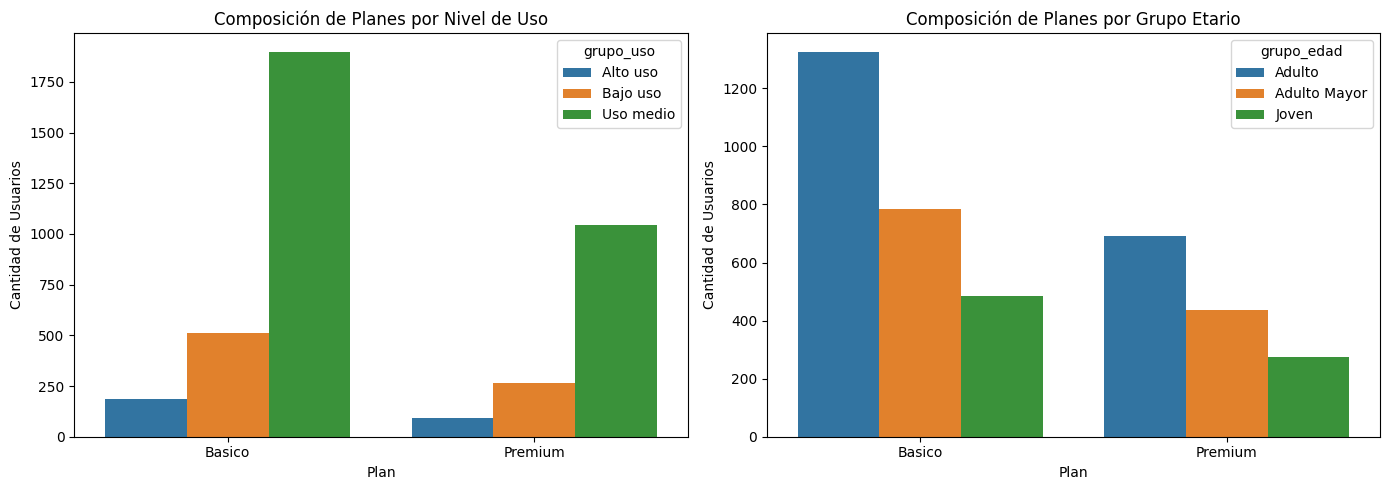

In [ ]:
# Composición de cada plan por nivel de uso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Plan vs Grupo de Uso
uso_plan = user_profile.groupby(['plan', 'grupo_uso']).size().reset_index(name='count')
sns.barplot(data=uso_plan, x='plan', y='count', hue='grupo_uso', ax=axes[0])
axes[0].set_title('Composición de Planes por Nivel de Uso')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Cantidad de Usuarios')

# Gráfico 2: Plan vs Grupo Etario
edad_plan = user_profile.groupby(['plan', 'grupo_edad']).size().reset_index(name='count')
sns.barplot(data=edad_plan, x='plan', y='count', hue='grupo_edad', ax=axes[1])
axes[1].set_title('Composición de Planes por Grupo Etario')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

#### Insights — Composición de Planes:
- El segmento de **Uso Medio domina en ambos planes**, con una mayoría especialmente marcada en el plan Básico
- **Hallazgo estratégico:** Existe una mayor cantidad de usuarios de **Alto Uso en el plan Básico que en Premium**, representando una oportunidad directa de up-selling no capitalizada
- El plan **Premium muestra una distribución etaria más uniforme** entre Adultos, Adultos Mayores y Jóvenes, mientras que el plan Básico está más concentrado en el segmento Adulto
- **Recomendación:** Priorizar migración de usuarios de Alto Uso en plan Básico hacia Premium mediante campañas de ahorro potencial

### ¿Cómo es la distribución geográfica de los usuarios?

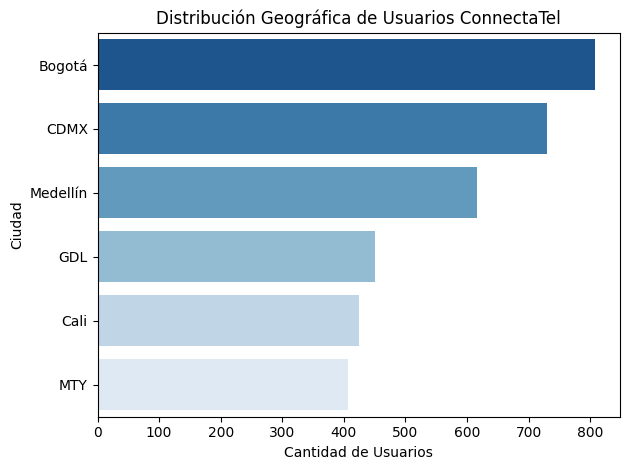

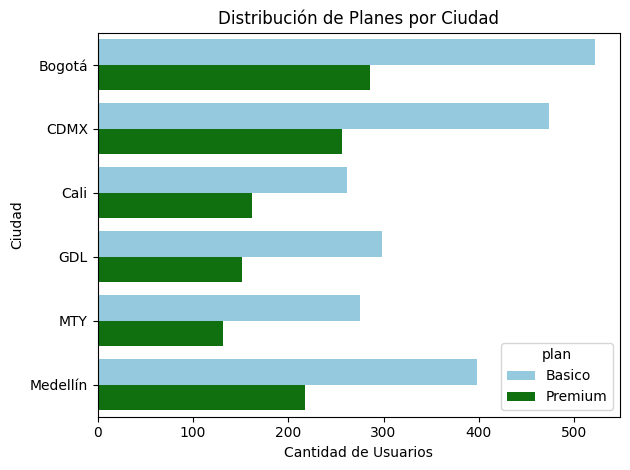

In [ ]:
# Distribución de usuarios por ciudad (excluyendo "unknown")
ciudad_dist = user_profile[user_profile['city'] != 'unknown']\
    ['city'].value_counts().reset_index()
ciudad_dist.columns = ['ciudad', 'usuarios']

# Visualización
sns.barplot(data=ciudad_dist, y='ciudad', x='usuarios',
            palette='Blues_r')
plt.title('Distribución Geográfica de Usuarios ConnectaTel')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

# Distribución por ciudad y plan
ciudad_plan = user_profile[user_profile['city'] != 'unknown']\
    .groupby(['city', 'plan']).size().reset_index(name='count')

sns.barplot(data=ciudad_plan, y='city', x='count',
            hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Planes por Ciudad')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

#### Insights —
- **Distribución Geográfica:**
  - La base de clientes se concentra en las capitales nacionales:
    - **Bogotá lidera con ~800 usuarios** y CDMX ocupa el segundo lugar con ~725 usuarios
  - **Medellín** es la tercera ciudad con ~600 usuarios, destacándose como un mercado secundario relevante
  - GDL, Cali y MTY son las ciudades con menor base de usuarios (~400-450 cada una), representando oportunidades de expansión
  - La distribución Básico/Premium es consistente en todas las ciudades, manteniéndose la proporción ~65/35 observada a nivel global

- **Recomendaciones geográficas:**
  - **Bogotá y CDMX** → campaña de fidelización y fortalecimiento del núcleo ya establecido; mayor concentración de usuarios
    Premium (~300 y ~250 respectivamente)
  - **GDL, Cali y MTY** → campaña de adquisición agresiva para expandir la base de clientes en mercados con menor penetración
  - **Medellín** → mercado con potencial de crecimiento acelerado dado su tamaño intermedio y posible subrepresentación Premium
